In [1]:
import pandas as pd
import re
import json

In [2]:
# Load datasets
batch1_1 = pd.read_csv('batch1_1.csv')
batch1_2 = pd.read_csv('batch1_2.csv')
batch1_3 = pd.read_csv('batch1_3.csv')

In [3]:
# Display rows of first csv file
print(batch1_1.head())

# Check info for batch1_1
batch1_1.info()

         File Name                                          Json Data  \
0  batch1-0494.jpg  \n{\n  "invoice": {\n    "client_name": "Clark...   
1  batch1-0489.jpg  \n{\n  "invoice": {\n    "client_name": "Willi...   
2  batch1-0499.jpg  \n{\n  "invoice": {\n    "client_name": "Heste...   
3  batch1-0497.jpg  \n{\n  "invoice": {\n    "client_name": "Olson...   
4  batch1-0081.jpg  \n{\n  "invoice": {\n    "client_name": "Wilso...   

                                          OCRed Text  
0  Invoice no: 84652373 Date of issue: 02/23/2021...  
1  Invoice no: 37451664 Date of issue: 06/11/2020...  
2  Invoice no: 40108666 Date of issue: 02/07/2020...  
3  Invoice no: 73285932 Date of issue: 07/25/2017...  
4  Invoice no: 15288019 Date of issue: 09/07/2014...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   File Name   499 non-null    object
 1   Js

In [4]:
# Display rows of second csv file
print(batch1_2.head())

# Check info for batch1_2
batch1_2.info()

         File Name                                          Json Data  \
0  batch1-0500.jpg  \n{\n  "invoice": {\n    "client_name": "Ellis...   
1  batch1-0501.jpg  \n{\n  "invoice": {\n    "client_name": "Thomp...   
2  batch1-0502.jpg  \n{\n  "invoice": {\n    "client_name": "Hayne...   
3  batch1-0503.jpg  \n{\n  "invoice": {\n    "client_name": "Peter...   
4  batch1-0504.jpg  \n{\n  "invoice": {\n    "client_name": "Bradl...   

                                          OCRed Text  
0  Invoice no: 34476404 Date of issue: 07/24/2018...  
1  Invoice no: 18999056 Date of issue: 07/29/2011...  
2  Invoice no: 33289699 Date of issue: 12/24/2012...  
3  Invoice no: 22758345 Date of issue: 12/21/2015...  
4  Invoice no: 79036267 Date of issue: 09/16/2016...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   File Name   426 non-null    object
 1   Js

In [5]:
# Display rows of third csv file
print(batch1_3.head())

# Check info for batch1_3
batch1_3.info()

         File Name                                          Json Data  \
0  batch1-1142.jpg  \n{\n  "invoice": {\n    "client_name": "Mille...   
1  batch1-1147.jpg  \n{\n  "invoice": {\n    "client_name": "Cruz,...   
2  batch1-1080.jpg  \n{\n  "invoice": {\n    "client_name": "Carey...   
3  batch1-1146.jpg  \n{\n  "invoice": {\n    "client_name": "Moore...   
4  batch1-1090.jpg  \n{\n  "invoice": {\n    "client_name": "Thoma...   

                                          OCRed Text  
0  Invoice no: 96556696 Date of issue: 02/25/2016...  
1  Invoice no: 95894022 Date of issue: 07/17/2014...  
2  Invoice no: 17585415 Date of issue: 09/26/2016...  
3  Invoice no: 27702906 Date of issue: 08/06/2015...  
4  Invoice no: 34310027 Date of issue: 09/06/2016...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   File Name   489 non-null    object
 1   Js

In [6]:
# Merge all the csv files
merge_data = pd.concat([batch1_1, batch1_2, batch1_3], ignore_index=True)

# Show merged dataset
print(merge_data.head())

         File Name                                          Json Data  \
0  batch1-0494.jpg  \n{\n  "invoice": {\n    "client_name": "Clark...   
1  batch1-0489.jpg  \n{\n  "invoice": {\n    "client_name": "Willi...   
2  batch1-0499.jpg  \n{\n  "invoice": {\n    "client_name": "Heste...   
3  batch1-0497.jpg  \n{\n  "invoice": {\n    "client_name": "Olson...   
4  batch1-0081.jpg  \n{\n  "invoice": {\n    "client_name": "Wilso...   

                                          OCRed Text  
0  Invoice no: 84652373 Date of issue: 02/23/2021...  
1  Invoice no: 37451664 Date of issue: 06/11/2020...  
2  Invoice no: 40108666 Date of issue: 02/07/2020...  
3  Invoice no: 73285932 Date of issue: 07/25/2017...  
4  Invoice no: 15288019 Date of issue: 09/07/2014...  


In [7]:
# Count NaNs in each column
print(merge_data.isna().sum())

File Name     0
Json Data     0
OCRed Text    0
dtype: int64


In [8]:
# Check shape, columns and total rows
merge_data.info()
print("The total number of rows after merge:", len(merge_data))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1414 entries, 0 to 1413
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   File Name   1414 non-null   object
 1   Json Data   1414 non-null   object
 2   OCRed Text  1414 non-null   object
dtypes: object(3)
memory usage: 33.3+ KB
The total number of rows after merge: 1414


In [9]:
# Check duplicates rows
num_duplicates = merge_data.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 1


In [10]:
# Display duplicate rows
duplicates = merge_data[merge_data.duplicated(keep=False)]
print("Duplicate rows:")
print(duplicates)

Duplicate rows:
           File Name                                          Json Data  \
574  batch1-0575.jpg  \n{\n  "invoice": {\n    "client_name": "Grego...   
575  batch1-0575.jpg  \n{\n  "invoice": {\n    "client_name": "Grego...   

                                            OCRed Text  
574  Invoice no: 48223084 Date of issue: 12/05/2018...  
575  Invoice no: 48223084 Date of issue: 12/05/2018...  


In [11]:
# Remove duplicate rows
merge_data = merge_data.drop_duplicates()

In [12]:
# Check remaining duplicates
num_duplicates_after = merge_data.duplicated().sum()
print("Number of duplicate rows after removal:", num_duplicates_after)

Number of duplicate rows after removal: 0


In [13]:
import pprint

# Function to parse numbers 
def parse_number(num_str):
    """
    Convert strings like '70 577,35' into float 70577.35
    """
    if not num_str:
        return None
    # Remove spaces (thousands separator)
    num_str = num_str.replace(' ', '')
    # Replace comma with dot for decimal
    num_str = num_str.replace(',', '.')
    try:
        return float(num_str)
    except:
        return None

# Function to extract invoice info 
def extract_invoice_info(json_text):
    data = {}

    # Extract client name
    client = re.search(r'"client_name"\s*:\s*"([^"]+)"', json_text)
    data['Client_name'] = client.group(1) if client else None

    # Extract seller name
    seller = re.search(r'"seller_name"\s*:\s*"([^"]+)"', json_text)
    data['Seller_name'] = seller.group(1) if seller else None

    # Extract invoice number
    invoice_no = re.search(r'"invoice_number"\s*:\s*"([^"]+)"', json_text)
    data['Invoice_no'] = invoice_no.group(1) if invoice_no else None

    # Extract invoice date
    invoice_date = re.search(r'"invoice_date"\s*:\s*"([^"]+)"', json_text)
    data['Invoice_date'] = invoice_date.group(1) if invoice_date else None

    # Extract total from subtotal
    total = re.search(r'"total"\s*:\s*"([^"]+)"', json_text)
    data['Total'] = parse_number(total.group(1)) if total else None

    # Extract items
    items = re.findall(
        r'"description"\s*:\s*"([^"]+)"\s*,\s*"quantity"\s*:\s*"([^"]+)"\s*,\s*"total_price"\s*:\s*"([^"]+)"',
        json_text
    )
    data['Items'] = [
        {
            'description': i[0].replace('\n', ' ').strip(),
            'quantity': parse_number(i[1]),
            'total_price': parse_number(i[2])
        } 
        for i in items
    ]

    return data

# Apply function to the dataframe 
merge_data['Json_Parsed'] = merge_data['Json Data'].apply(extract_invoice_info)

# ---------- Preview the first parsed row ----------
pprint.pprint(merge_data['Json_Parsed'].iloc[0])

# Flatten items into a separate dataframe 
items_list = []
for idx, row in merge_data.iterrows():
    for item in row['Json_Parsed']['Items']:
        items_list.append({
            'File Name': row['File Name'],
            'Invoice_no': row['Json_Parsed']['Invoice_no'],
            'Client_name': row['Json_Parsed']['Client_name'],
            'Seller_name': row['Json_Parsed']['Seller_name'],
            'Item_desc': item['description'],
            'Quantity': item['quantity'],
            'Total_price': item['total_price']
        })

items_df = pd.DataFrame(items_list)

# Display items dataframe
items_df.head()

{'Client_name': 'Clark-Foster',
 'Invoice_date': '02/23/2021',
 'Invoice_no': '84652373',
 'Items': [{'description': 'Stemware Rack Display Kitchen\\nWine Glass Holder '
                           'Bottle\\nCarbon Steel Free Punch',
            'quantity': 1.0,
            'total_price': 46.55},
           {'description': 'VTG (4) 7 Ounce Since 1852\\nMilk Bottle Wine '
                           'Carafe Juice\\nGlass with Cork Lids',
            'quantity': 1.0,
            'total_price': 15.4},
           {'description': 'Vintage Crystal Red Wine\\nGlasses NOS West '
                           'Germany\\n1983 6 10 ounce elegant stems',
            'quantity': 1.0,
            'total_price': 39.0},
           {'description': '3 Ikea Stainless Steel 4-bottle\\nWine Rack '
                           '300.557.60 - great\\ncondition gift it!',
            'quantity': 4.0,
            'total_price': 110.0}],
 'Seller_name': 'Nguyen-Roach',
 'Total': 232.95}


,File Name,Invoice_no,Client_name,Seller_name,Item_desc,Quantity,Total_price
0,batch1-0494.jpg,84652373,Clark-Foster,Nguyen-Roach,Stemware Rack Display Kitchen\nWine Glass Hold...,1.0,46.55
1,batch1-0494.jpg,84652373,Clark-Foster,Nguyen-Roach,VTG (4) 7 Ounce Since 1852\nMilk Bottle Wine C...,1.0,15.40
2,batch1-0494.jpg,84652373,Clark-Foster,Nguyen-Roach,Vintage Crystal Red Wine\nGlasses NOS West Ger...,1.0,39.00
3,batch1-0494.jpg,84652373,Clark-Foster,Nguyen-Roach,3 Ikea Stainless Steel 4-bottle\nWine Rack 300...,4.0,110.00
4,batch1-0489.jpg,37451664,"Williams, Schneider and Gomez",Scott-Howard,PUMA Boys Youth Universal FG Jr Soccer Cleats ...,2.0,43.98


In [14]:
def parse_number(num_str):
    if not num_str:
        return None
    num_str = num_str.replace(' ', '').replace(',', '.')
    try:
        return float(num_str)
    except:
        return None

def clean_ocr_invoice_one_line(ocr_text):
    data = {}
    
    # Invoice Header 
    data['Invoice_no'] = re.search(r'Invoice no[:\s]*(\d+)', ocr_text).group(1)
    data['Invoice_date'] = re.search(r'Date of issue[:\s]*([\d/]+)', ocr_text).group(1)
    
    # Seller/Client
    seller_client_match = re.search(r'Seller:\s*(.*?)\s*Client:\s*([A-Za-z\-\s]+)', ocr_text)
    if seller_client_match:
        data['Seller_name'] = seller_client_match.group(1).strip() or None
        data['Client_name'] = seller_client_match.group(2).strip()
    else:
        # Extract Client if seller is not there
        client_match = re.search(r'Client:\s*([A-Za-z\-\s]+)', ocr_text)
        data['Seller_name'] = None
        data['Client_name'] = client_match.group(1).strip() if client_match else None

    # Total
    total_match = re.search(r'Total \$\s*([\d\s,\.]+)', ocr_text)
    data['Total'] = parse_number(total_match.group(1)) if total_match else None

    # Items
    items = []
    # Search for all occurrences of "quantity each ... gross"
    item_pattern = re.compile(r'([A-Za-z0-9\s"\-\n\(\)\.]+?)\s+(\d+,\d+|\d+)\s+each.*?([\d,\.]+)')
    for m in item_pattern.finditer(ocr_text):
        desc = m.group(1).replace('\n',' ').strip()
        qty = parse_number(m.group(2))
        total_price = parse_number(m.group(3))
        items.append({'description': desc, 'quantity': qty, 'total_price': total_price})
    
    data['Items'] = items
    return data

# Example usage
ocr_text = """Invoice no: 84652373 Date of issue: 02/23/2021 Seller: Client: Nguyen-Roach Clark-Foster 247 David Highway 77477 Cliff Apt. 853 ... Total $ 232,95 Stemware Rack Display Kitchen 1,00 each 46,55 Wine Glass Holder Bottle Carbon Steel Free Punch 1,00 each 15,40 Vintage Crystal Red Wine 1,00 each 39,00 3 Ikea Stainless Steel 4-bottle 4,00 each 110,00 Lolita "Wine Bouquet" Hand 1,00 each 22,00"""
parsed = clean_ocr_invoice_one_line(ocr_text)

pprint.pprint(parsed)


{'Client_name': 'Nguyen-Roach Clark-Foster',
 'Invoice_date': '02/23/2021',
 'Invoice_no': '84652373',
 'Items': [{'description': '95 Stemware Rack Display Kitchen',
            'quantity': 1.0,
            'total_price': 46.55},
           {'description': 'Wine Glass Holder Bottle Carbon Steel Free Punch',
            'quantity': 1.0,
            'total_price': 15.4},
           {'description': 'Vintage Crystal Red Wine',
            'quantity': 1.0,
            'total_price': 39.0},
           {'description': '3 Ikea Stainless Steel 4-bottle',
            'quantity': 4.0,
            'total_price': 110.0},
           {'description': 'Lolita "Wine Bouquet" Hand',
            'quantity': 1.0,
            'total_price': 22.0}],
 'Seller_name': None,
 'Total': 232.95}


In [15]:
def clean_ocr_invoice_one_line_fixed(ocr_text):
    data = {}
    
    # Header 
    data['Invoice_no'] = re.search(r'Invoice no[:\s]*(\d+)', ocr_text).group(1)
    data['Invoice_date'] = re.search(r'Date of issue[:\s]*([\d/]+)', ocr_text).group(1)
    
    # Seller/Client
    seller_client_match = re.search(r'Seller:\s*Client:\s*([A-Za-z\-\s]+)', ocr_text)
    if seller_client_match:
        full_name = seller_client_match.group(1).strip()
        parts = full_name.split(' ', 1)
        if len(parts) == 2:
            data['Seller_name'] = parts[0].strip()
            data['Client_name'] = parts[1].strip()
        else:
            data['Seller_name'] = None
            data['Client_name'] = full_name
    else:
        data['Seller_name'] = None
        client_match = re.search(r'Client:\s*([A-Za-z\-\s]+)', ocr_text)
        data['Client_name'] = client_match.group(1).strip() if client_match else None

    # Total
    total_match = re.search(r'Total \$\s*([\d\s,\.]+)', ocr_text)
    data['Total'] = parse_number(total_match.group(1)) if total_match else None

    # Items
    items = []
    item_pattern = re.compile(r'([A-Za-z0-9\s"\-\n\(\)\.]+?)\s+(\d+,\d+|\d+)\s+each.*?([\d,\.]+)')
    for m in item_pattern.finditer(ocr_text):
        desc = m.group(1).replace('\n',' ').strip()
        qty = parse_number(m.group(2))
        total_price = parse_number(m.group(3))
        items.append({'description': desc, 'quantity': qty, 'total_price': total_price})
    
    data['Items'] = items
    return data

# Example usage
parsed_fixed = clean_ocr_invoice_one_line_fixed(ocr_text)
import pprint
pprint.pprint(parsed_fixed)


{'Client_name': 'Clark-Foster',
 'Invoice_date': '02/23/2021',
 'Invoice_no': '84652373',
 'Items': [{'description': '95 Stemware Rack Display Kitchen',
            'quantity': 1.0,
            'total_price': 46.55},
           {'description': 'Wine Glass Holder Bottle Carbon Steel Free Punch',
            'quantity': 1.0,
            'total_price': 15.4},
           {'description': 'Vintage Crystal Red Wine',
            'quantity': 1.0,
            'total_price': 39.0},
           {'description': '3 Ikea Stainless Steel 4-bottle',
            'quantity': 4.0,
            'total_price': 110.0},
           {'description': 'Lolita "Wine Bouquet" Hand',
            'quantity': 1.0,
            'total_price': 22.0}],
 'Seller_name': 'Nguyen-Roach',
 'Total': 232.95}


In [16]:
def flatten_ocr_invoice(parsed_dict, file_name=None):
    
    # Flatten a parsed OCR invoice dictionary into rows, one row per item.
    rows = []
    invoice_no = parsed_dict.get('Invoice_no')
    client_name = parsed_dict.get('Client_name')
    seller_name = parsed_dict.get('Seller_name')
    total = parsed_dict.get('Total')
    
    items = parsed_dict.get('Items', [])
    
    if not items:  # Create a single row with empty item fields if there are no items
        rows.append({
            'File Name': file_name,
            'Invoice_no': invoice_no,
            'Client_name': client_name,
            'Seller_name': seller_name,
            'Item_desc': None,
            'Quantity': None,
            'Total_price': total
        })
    else:
        for item in items:
            rows.append({
                'File Name': file_name,
                'Invoice_no': invoice_no,
                'Client_name': client_name,
                'Seller_name': seller_name,
                'Item_desc': item.get('description'),
                'Quantity': item.get('quantity'),
                'Total_price': item.get('total_price')
            })
    return pd.DataFrame(rows)

# Example usage for a single invoice
flattened_df = flatten_ocr_invoice(parsed_fixed, file_name='batch1-0494.jpg')
print(flattened_df)


         File Name Invoice_no   Client_name   Seller_name  \
0  batch1-0494.jpg   84652373  Clark-Foster  Nguyen-Roach   
1  batch1-0494.jpg   84652373  Clark-Foster  Nguyen-Roach   
2  batch1-0494.jpg   84652373  Clark-Foster  Nguyen-Roach   
3  batch1-0494.jpg   84652373  Clark-Foster  Nguyen-Roach   
4  batch1-0494.jpg   84652373  Clark-Foster  Nguyen-Roach   

                                          Item_desc  Quantity  Total_price  
0                  95 Stemware Rack Display Kitchen       1.0        46.55  
1  Wine Glass Holder Bottle Carbon Steel Free Punch       1.0        15.40  
2                          Vintage Crystal Red Wine       1.0        39.00  
3                   3 Ikea Stainless Steel 4-bottle       4.0       110.00  
4                        Lolita "Wine Bouquet" Hand       1.0        22.00  


In [17]:
# For flattened OCR dataframe
print("Missing values in flattened OCR dataframe:")
print(flattened_df.isna().sum())

Missing values in flattened OCR dataframe:
File Name      0
Invoice_no     0
Client_name    0
Seller_name    0
Item_desc      0
Quantity       0
Total_price    0
dtype: int64


In [18]:
# For JSON-parsed dataframe 
print("\nMissing values in JSON-parsed dataframe:")
print(items_df.isna().sum())


Missing values in JSON-parsed dataframe:
File Name      0
Invoice_no     0
Client_name    0
Seller_name    0
Item_desc      0
Quantity       0
Total_price    0
dtype: int64


In [19]:
# Flatten JSON parsed data
json_items_list = []
for idx, row in merge_data.iterrows():
    for item in row['Json_Parsed']['Items']:
        json_items_list.append({
            'Invoice_no': row['Json_Parsed']['Invoice_no'],
            'Client_name': row['Json_Parsed']['Client_name'],
            'Seller_name': row['Json_Parsed']['Seller_name'],

            'Item_desc': item['description'].replace('\n', ' ').strip(),

            'Quantity_json': item['quantity'],
            'Total_price_json': item['total_price']
        })

json_items_df = pd.DataFrame(json_items_list)



In [20]:
from thefuzz import process, fuzz

In [21]:
def parse_number(num_str):
    """Convert strings like '70 577,35' into float 70577.35"""
    if not num_str:
        return None
    num_str = num_str.replace(' ', '').replace(',', '.')
    try:
        return float(num_str)
    except:
        return None

def clean_text(text):
    """Normalize text for fuzzy matching"""
    if not text:
        return ''
    # Remove newlines, tabs, carriage returns
    text = re.sub(r'[\n\r\t]+', ' ', text)
    # Replace multiple spaces with one
    text = re.sub(r'\s+', ' ', text)
    # Remove all special characters except letters and numbers
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    return text.strip().lower()


def match_items_best(json_desc, ocr_desc_list, threshold=40):
    best_match = None
    best_score = 0
    for desc in ocr_desc_list:
        score1 = fuzz.token_set_ratio(json_desc, desc)
        score2 = fuzz.partial_ratio(json_desc, desc)
        score = max(score1, score2)
        if score > best_score:
            best_score = score
            best_match = desc
    return best_match if best_score >= threshold else None

# Flatten OCR dataframe
ocr_items_df = flattened_df.copy()

# Clean OCR item descriptions
ocr_items_df['Item_desc_clean'] = ocr_items_df['Item_desc'].apply(clean_text)

# Flatten JSON dataframe
json_items_list = []
for idx, row in merge_data.iterrows():
    for item in row['Json_Parsed']['Items']:
        json_items_list.append({
            'Invoice_no': row['Json_Parsed']['Invoice_no'],
            'Client_name': row['Json_Parsed']['Client_name'],
            'Seller_name': row['Json_Parsed']['Seller_name'],
            'Item_desc': item['description'],
            'Quantity_json': item['quantity'],
            'Total_price_json': item['total_price']
        })

json_items_df = pd.DataFrame(json_items_list)
json_items_df['Item_desc_clean'] = json_items_df['Item_desc'].apply(clean_text)

# Fuzzy matching
ocr_desc_list_clean = ocr_items_df['Item_desc_clean'].tolist()
json_items_df['Matched_Item_desc'] = json_items_df['Item_desc_clean'].apply(
    lambda x: match_items_best(x, ocr_desc_list_clean)
)

# Merge matched JSON and OCR data
merged_df = pd.merge(
    json_items_df,
    ocr_items_df,
    left_on='Matched_Item_desc',
    right_on='Item_desc_clean',
    how='inner',
    suffixes=('_json','_ocr')
)

In [22]:
# Compute errors first
merged_df['Quantity_diff'] = merged_df['Quantity_json'] - merged_df['Quantity']
merged_df['Quantity_error_pct'] = abs(merged_df['Quantity_diff']) / merged_df['Quantity_json'] * 100

merged_df['Total_price_diff'] = merged_df['Total_price_json'] - merged_df['Total_price']
merged_df['Total_price_error_pct'] = abs(merged_df['Total_price_diff']) / merged_df['Total_price_json'] * 100

# filter extreme errors
max_quantity_error = 300
max_total_price_error = 1000

filtered_df = merged_df[
    (merged_df['Quantity_error_pct'] <= max_quantity_error) &
    (merged_df['Total_price_error_pct'] <= max_total_price_error)
]

# Summary statistics
print("Matched JSON items after filtering:", len(filtered_df))
print("Summary statistics for Quantity and Total Price errors:")
print(filtered_df[['Quantity_error_pct','Total_price_error_pct']].describe())


Matched JSON items after filtering: 4972
Summary statistics for Quantity and Total Price errors:
       Quantity_error_pct  Total_price_error_pct
count         4972.000000            4972.000000
mean            59.163650             106.640316
std             49.876011             123.629382
min              0.000000               0.000000
25%             33.333333              55.870445
50%             66.666667              87.046602
75%             75.000000              98.775318
max            300.000000            1000.000000


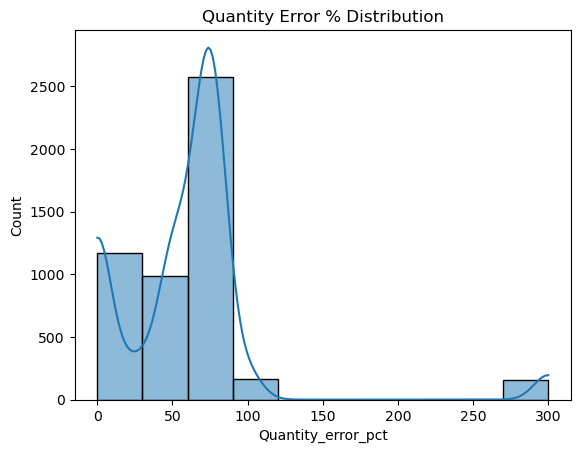

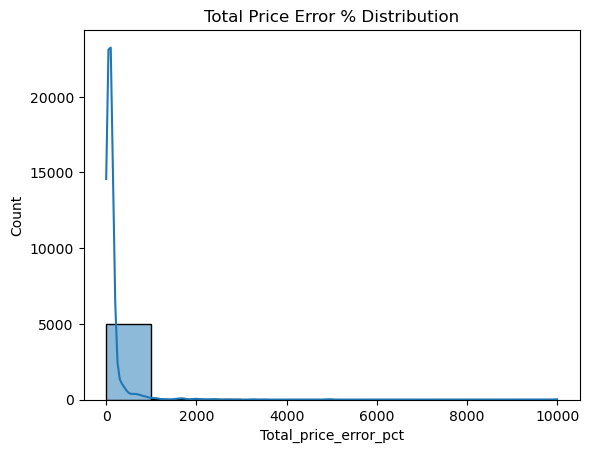

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(merged_df['Quantity_error_pct'], kde=True, bins=10)
plt.title("Quantity Error % Distribution")
plt.show()

sns.histplot(merged_df['Total_price_error_pct'], kde=True, bins=10)
plt.title("Total Price Error % Distribution")
plt.show()


In [24]:
# Create classification label
threshold = 5  # adjust as you want
merged_df['Total_price_label'] = (merged_df['Total_price_error_pct'] > threshold).astype(int)

# Define features + target
features = ['Quantity', 'Quantity_json']
target = 'Total_price_label'

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    merged_df[features], merged_df[target],
    test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.9722497522299306
Precision: 0.9722497522299306
Recall: 1.0
F1-score: 0.985929648241206


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Text feature
tfidf = TfidfVectorizer(max_features=3000)
X_text = tfidf.fit_transform(merged_df['Item_desc_clean_ocr'].fillna("")).toarray()

# Label
y = merged_df['Total_price_label'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)

# Neural Network model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train with epochs
history = model.fit(
    X_train, y_train,
    epochs=20,              
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", test_acc)


Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9777 - loss: 0.1527 - val_accuracy: 0.9678 - val_loss: 0.1452
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9796 - loss: 0.1001 - val_accuracy: 0.9678 - val_loss: 0.1461
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.1013 - val_accuracy: 0.9678 - val_loss: 0.1483
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.1004 - val_accuracy: 0.9678 - val_loss: 0.1451
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.1008 - val_accuracy: 0.9678 - val_loss: 0.1427
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.1020 - val_accuracy: 0.9678 - val_loss: 0.1427
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.1009 - val_accuracy: 0.9678 - val_loss: 0.1420
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.0999 - val_accuracy: 0.

In [26]:
merged_df.to_csv("merged_df.csv", index=False)

model.save("nn_model.keras")

import pickle
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
